# Operator comparison — $p^\star$ vs $n$ and recovery curves by $\eta$
> **Purpose:** compare three partitioning operators by how much sub-sampling each tolerates
> on the Kingman eta-pool — produces **Figure 1** ($p^\star$ vs $n$, scaling) and **Figure 2**
> (recovery-vs-$p$ grid + $p^\star$ summary).  **Data: generated** (dendropy Kingman; cached eta-pool).

| color | operator | Laplacian | threshold $\tau$ |
|---|---|---|---|
| gray  | `sign`   | $L=\mathrm{Deg}(S)-S$ | sign, $\tau=0$ (original STDR) |
| blue  | `sigma2` | $L=\mathrm{Deg}(S)-S$ | data-driven $\sigma_2$-gap |
| red   | `kmeans` | $L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$ | data-driven k-means($k$=2) |

This one notebook replaces the former `per_n` (sign), `per_n_lsym` (kmeans) and `per_n_median`
(median) notebooks via the `§1` toggles **`METRIC`** (`nmi`/`ari`/`agreement`) and **`AGG`**
(`mean`/`median`). `sign`/`kmeans` compute on demand (cache-warm); `sigma2` is **cached-only**
(`CACHED_ONLY`) — plotted only where already on disk, never recomputed — so newly-added $n$
(3000, 6000) extend the `sign`/`kmeans` lines while `sigma2` covers the original sizes.

## 1 · Setup & config

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.eta_pool_sweep import (
    discover_ns_and_samples, run_and_collect_sweeps, P_VALUES,
)
from analysis.theoretical_interpretation.utils.sweep_plots import (
    plot_pstar_vs_n, plot_nmi_grid, plot_curves_per_n, plot_curves_per_eta,
)

CACHE_ROOT = PROJECT_ROOT / "src" / "cache"

# --- toggles -------------------------------------------------------------------
ETA_TARGETS = [1, 5, 10, 15]
NS_INCLUDE  = [500, 1000, 2000, 3000, 4000, 6000, 8000]
METRIC      = "nmi"      # "nmi" | "ari" | "agreement"   (recovery metric)
AGG         = "mean"     # "mean" | "median"             (across pool samples)
THRESHOLD   = 0.95
# sigma2 is the expensive operator: plot only where already cached, never recompute.
CACHED_ONLY = {"sigma2"}

# operators to compare: (results-key, color, linestyle, marker)
METHODS = [
    ("sign",   "#4b5563", "-",  "o"),   # unnorm + sign (tau=0) — original STDR
    ("sigma2", "#1d4ed8", "--", "s"),   # unnorm + sigma2-gap
    ("kmeans", "#b91c1c", "-",  "^"),   # norm   + k-means (L_sym)
]
METHOD_NAMES = [m[0] for m in METHODS]
print(f"metric={METRIC}  agg={AGG}  cached_only={CACHED_ONLY}")

metric=nmi  agg=mean  cached_only={'sigma2'}


## 2 · Discover available $n$ and samples

In [2]:
ns_all, samples_by_n_eta = discover_ns_and_samples(CACHE_ROOT, eta_targets=ETA_TARGETS)
ns = [n for n in ns_all if n in NS_INCLUDE]
print(f"Found n values: {ns}")
print(f"  {'n':>6}  " + "  ".join(f"eta={e:>2}" for e in ETA_TARGETS))
for n in ns:
    counts = [len(samples_by_n_eta.get((n, e), [])) for e in ETA_TARGETS]
    print(f"  {n:>6}  " + "  ".join(f"{c:>6d}" for c in counts))

Found n values: [500, 1000, 2000, 3000, 4000, 6000, 8000]
       n  eta= 1  eta= 5  eta=10  eta=15
     500      10      10       3       3
    1000      10      10       3       3
    2000      10      10       3       3
    3000      10      10       3       3
    4000      10      10       3       3
    6000      10      10       3       3
    8000       1       1       1       1


## 3 · Compute — run (or load) the three-operator sweeps

In [3]:
results = run_and_collect_sweeps(
    ns=ns, eta_targets=ETA_TARGETS, methods=METHOD_NAMES,
    metric=METRIC, cached_only_methods=CACHED_ONLY, use_cache=True,
)
print("sweep complete:",
      {m: sum(v.shape[0] for v in d.values()) for m, d in results.items()})

  n= 500 eta= 1 done


  n= 500 eta= 5 done


  n= 500 eta=10 done


  n= 500 eta=15 done


  n=1000 eta= 1 done


...

  n=8000 eta= 1 done


  n=8000 eta= 5 done


  n=8000 eta=10 done


  n=8000 eta=15 done


sweep complete: {'sign': 160, 'sigma2': 108, 'kmeans': 160}


## 4 · Figures

### Figure 1 — $p^\star$ vs $n$ by operator (per $\eta$)

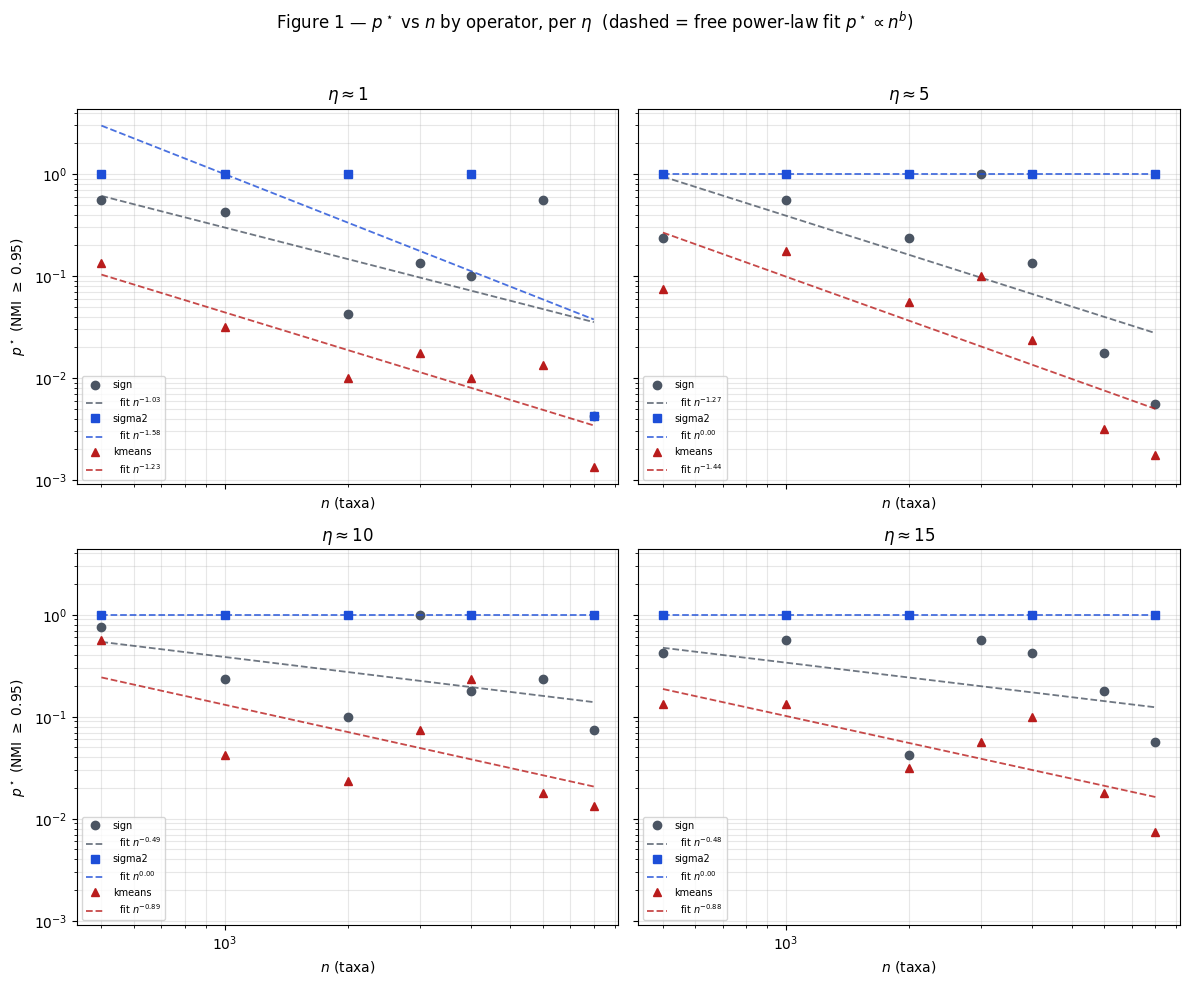

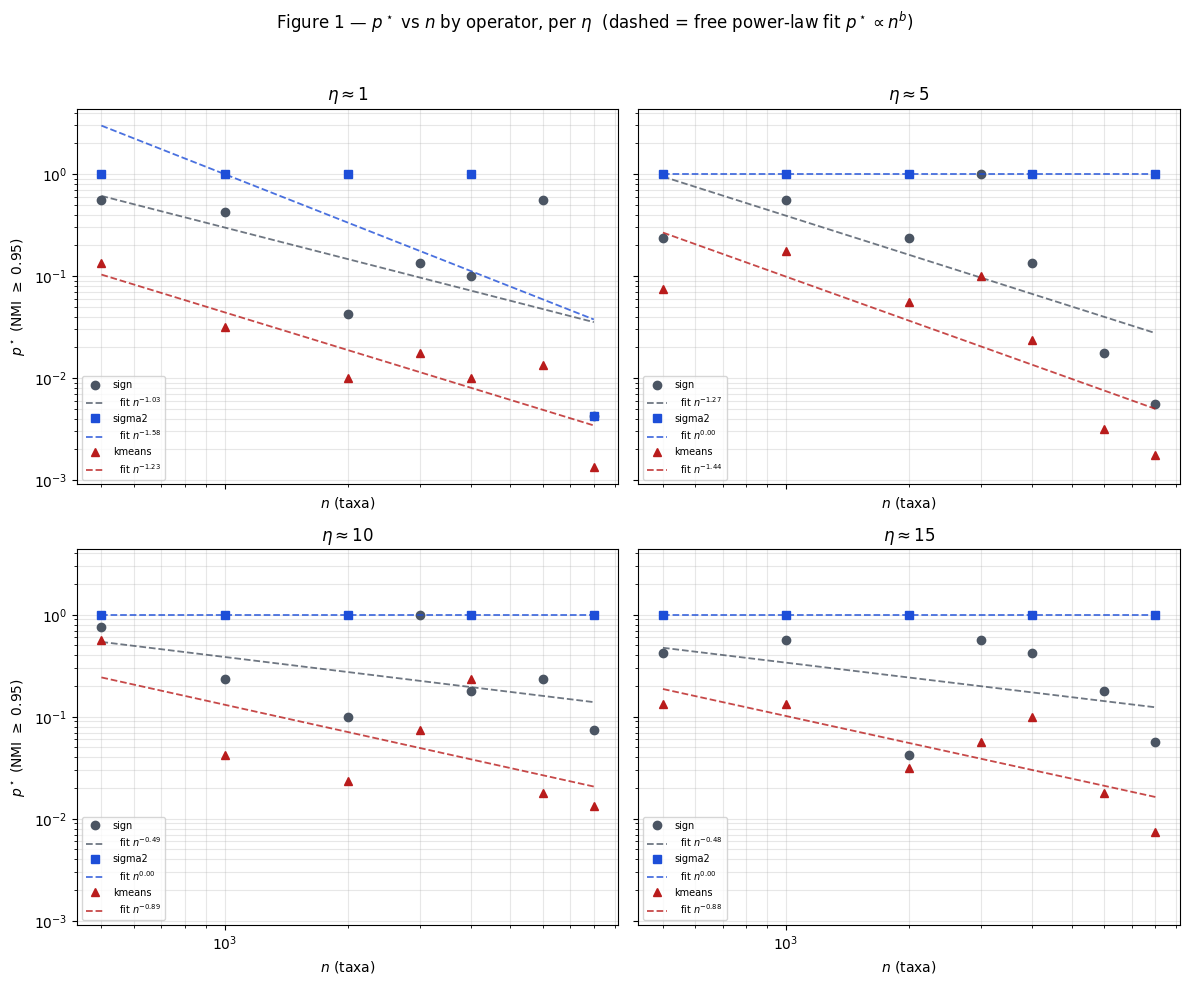

In [4]:
plot_pstar_vs_n(results, P_VALUES, ETA_TARGETS, ns, METHODS,
                agg=AGG, threshold=THRESHOLD)

### Figure 2 — recovery vs $p$ (rows $n$ × cols $\eta$) + $p^\star$ summary

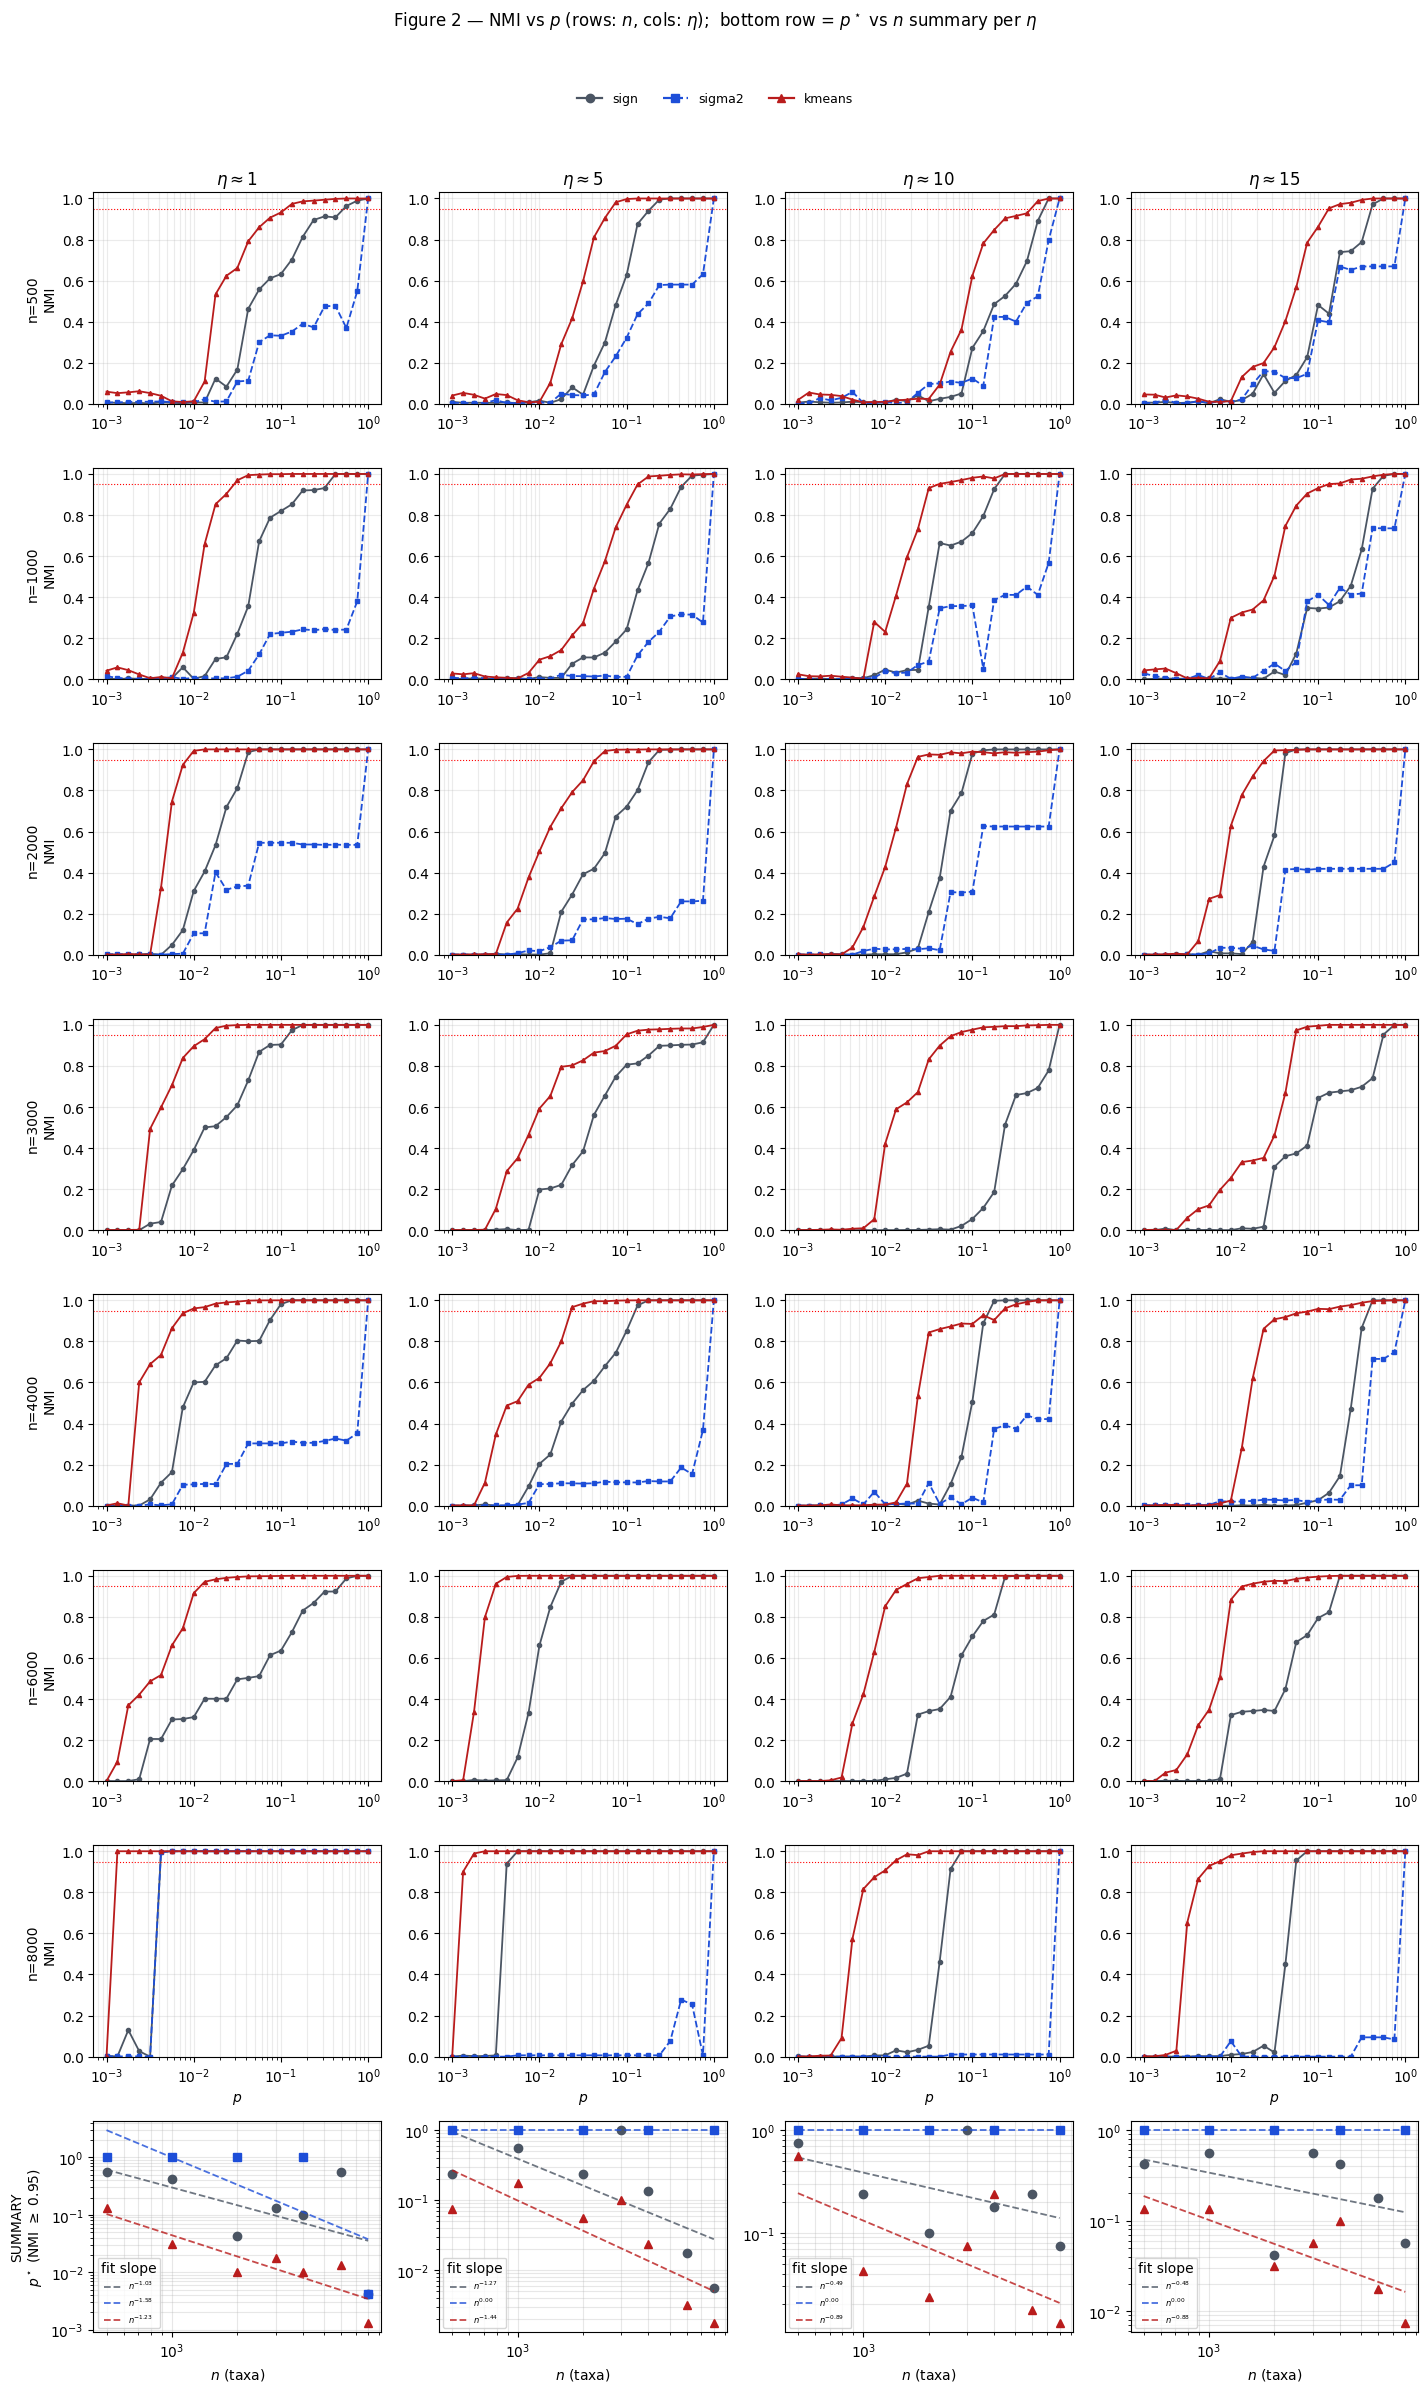

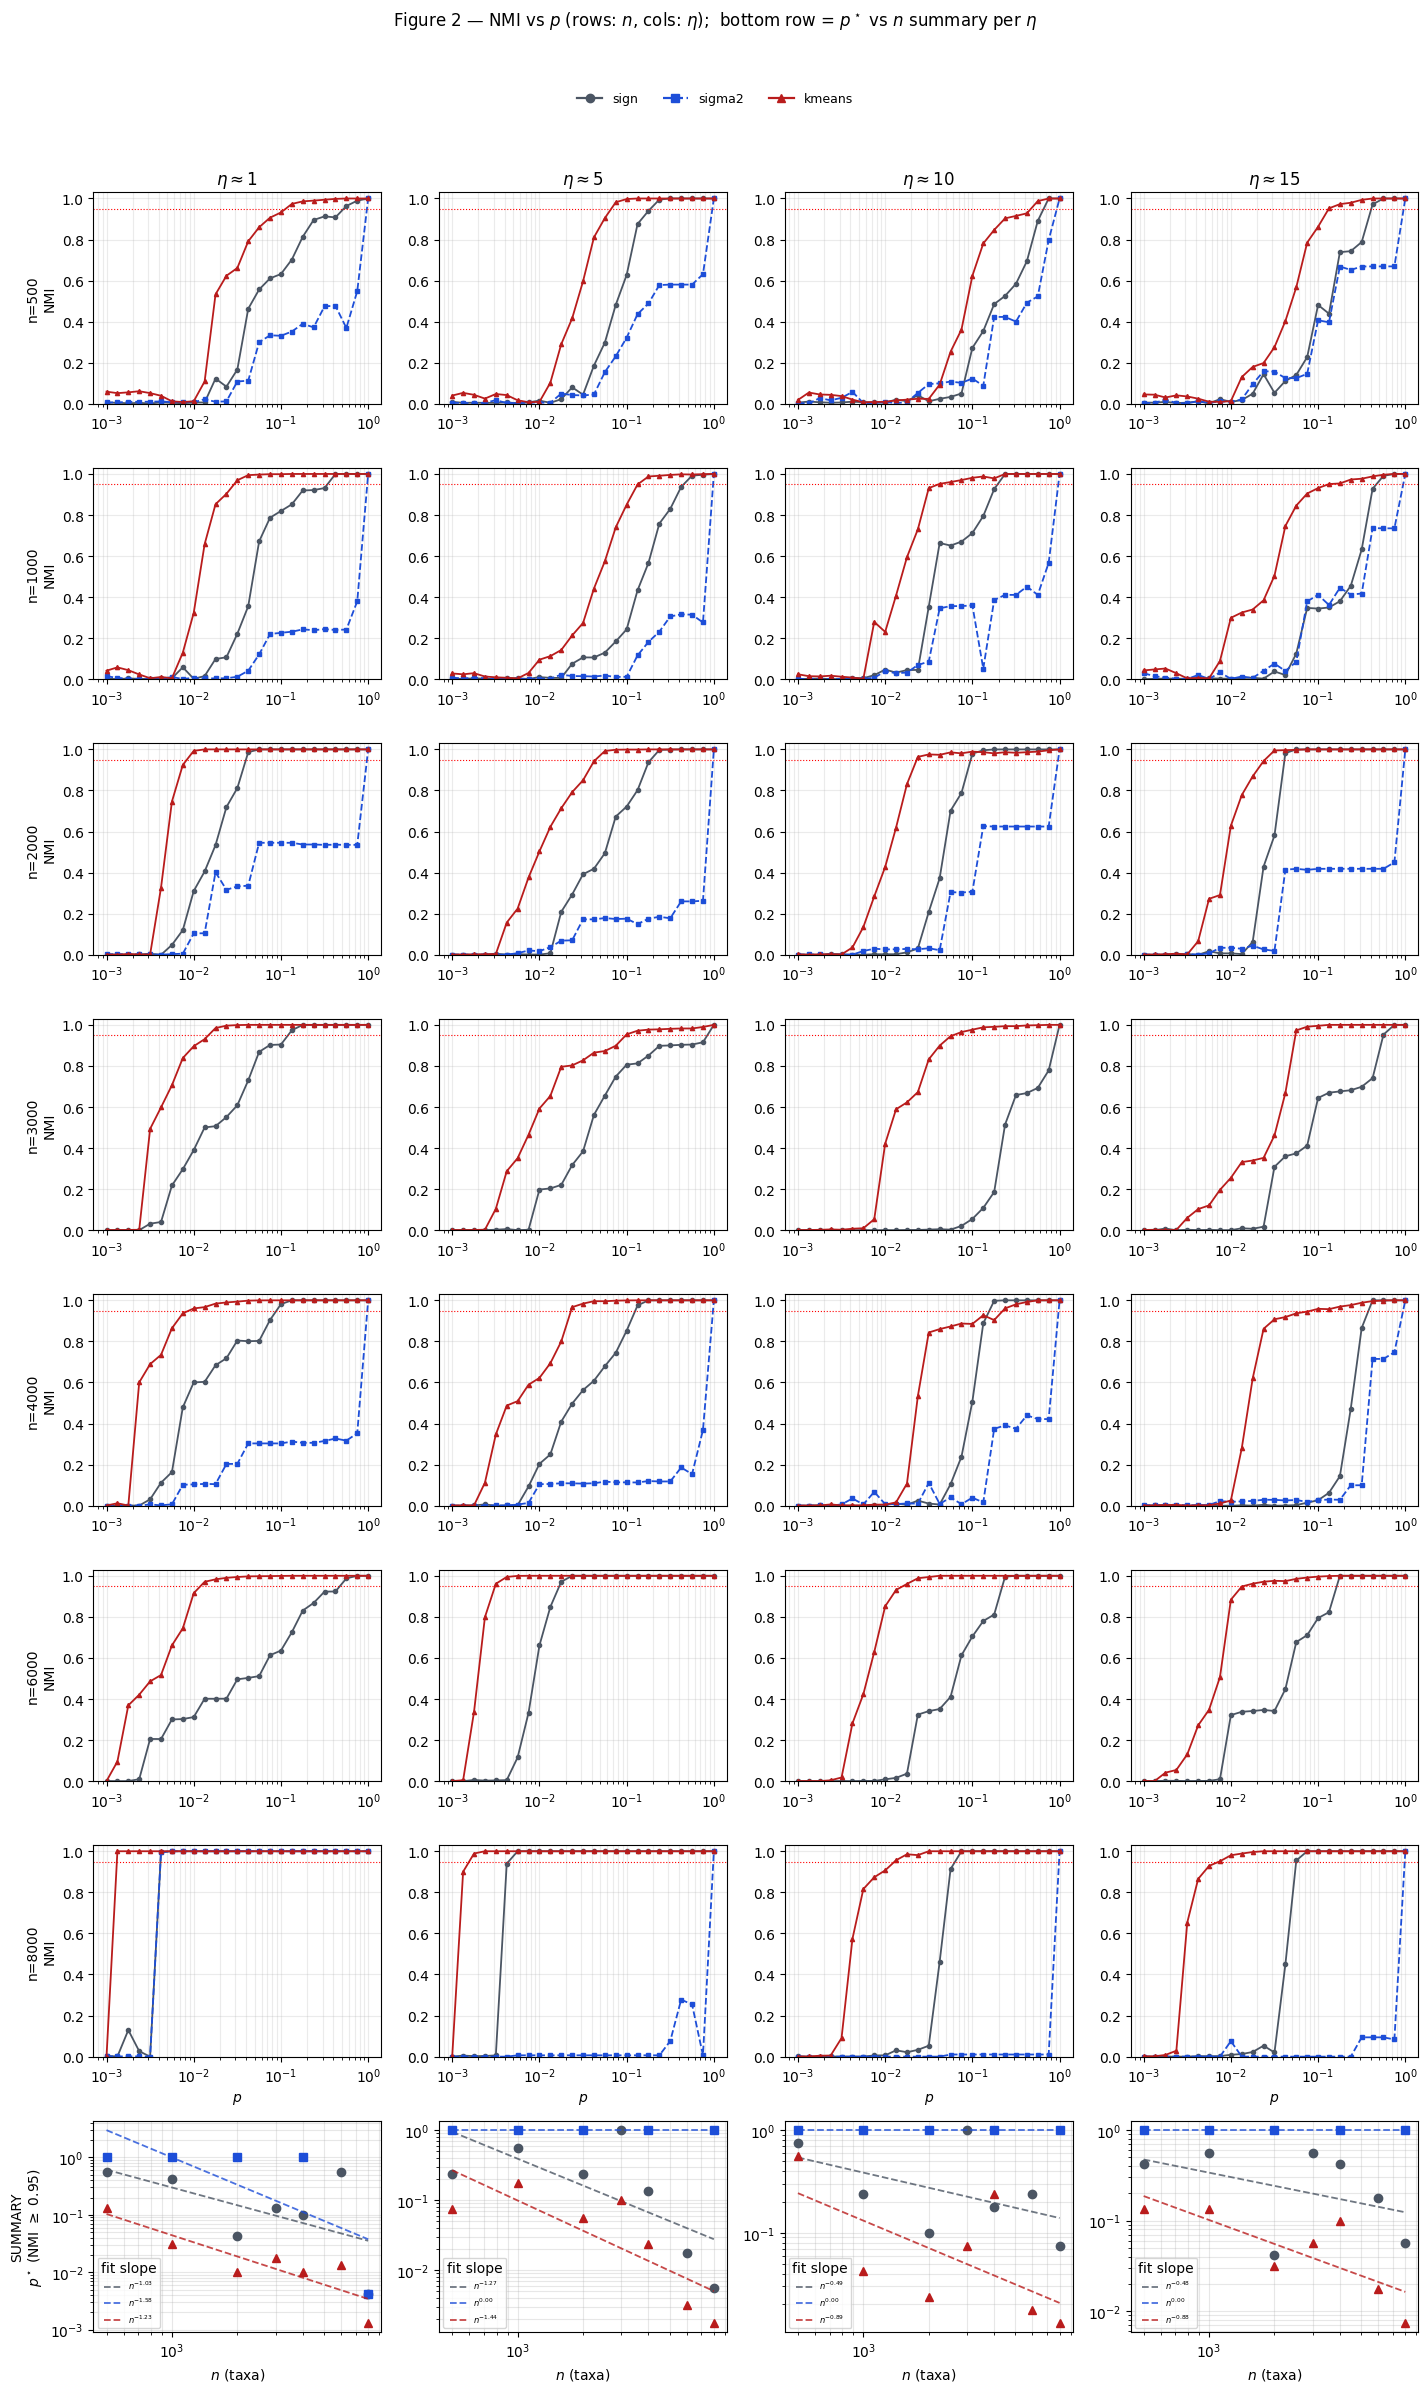

In [5]:
plot_nmi_grid(results, P_VALUES, ETA_TARGETS, ns, METHODS,
              agg=AGG, threshold=THRESHOLD, metric_label=METRIC.upper())

### Detail views — curves by $\eta$ (per $n$) and by $n$ (per $\eta$)

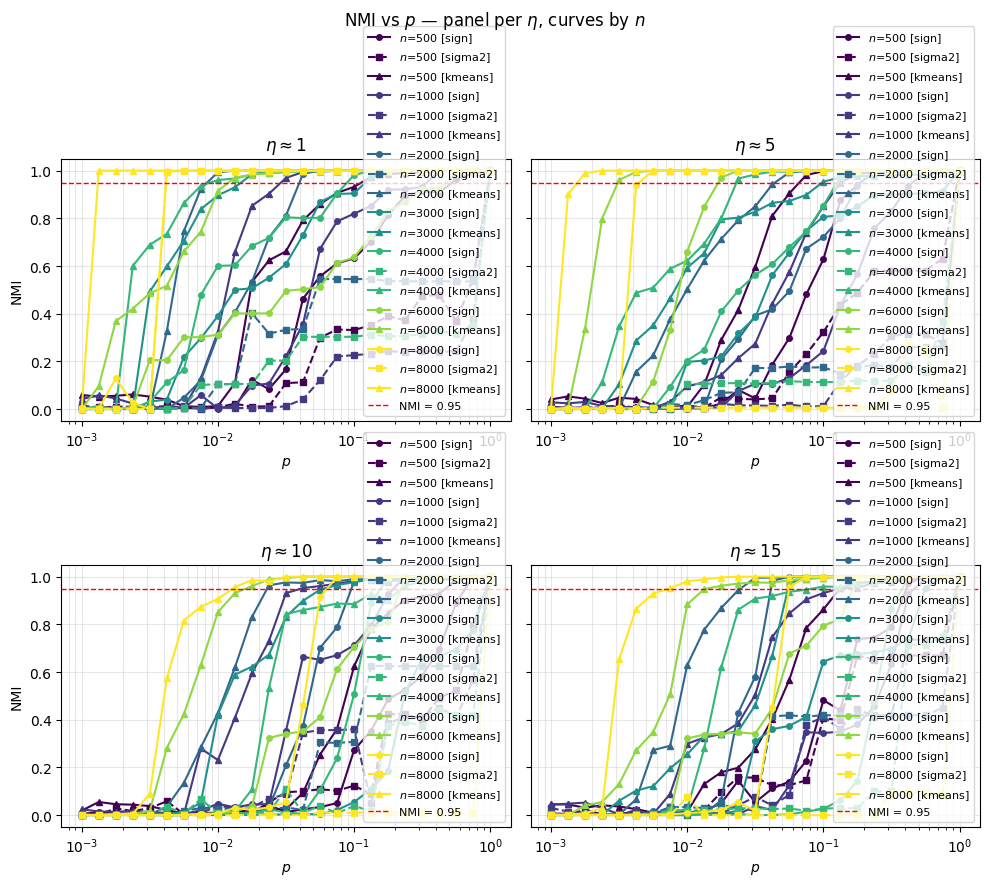

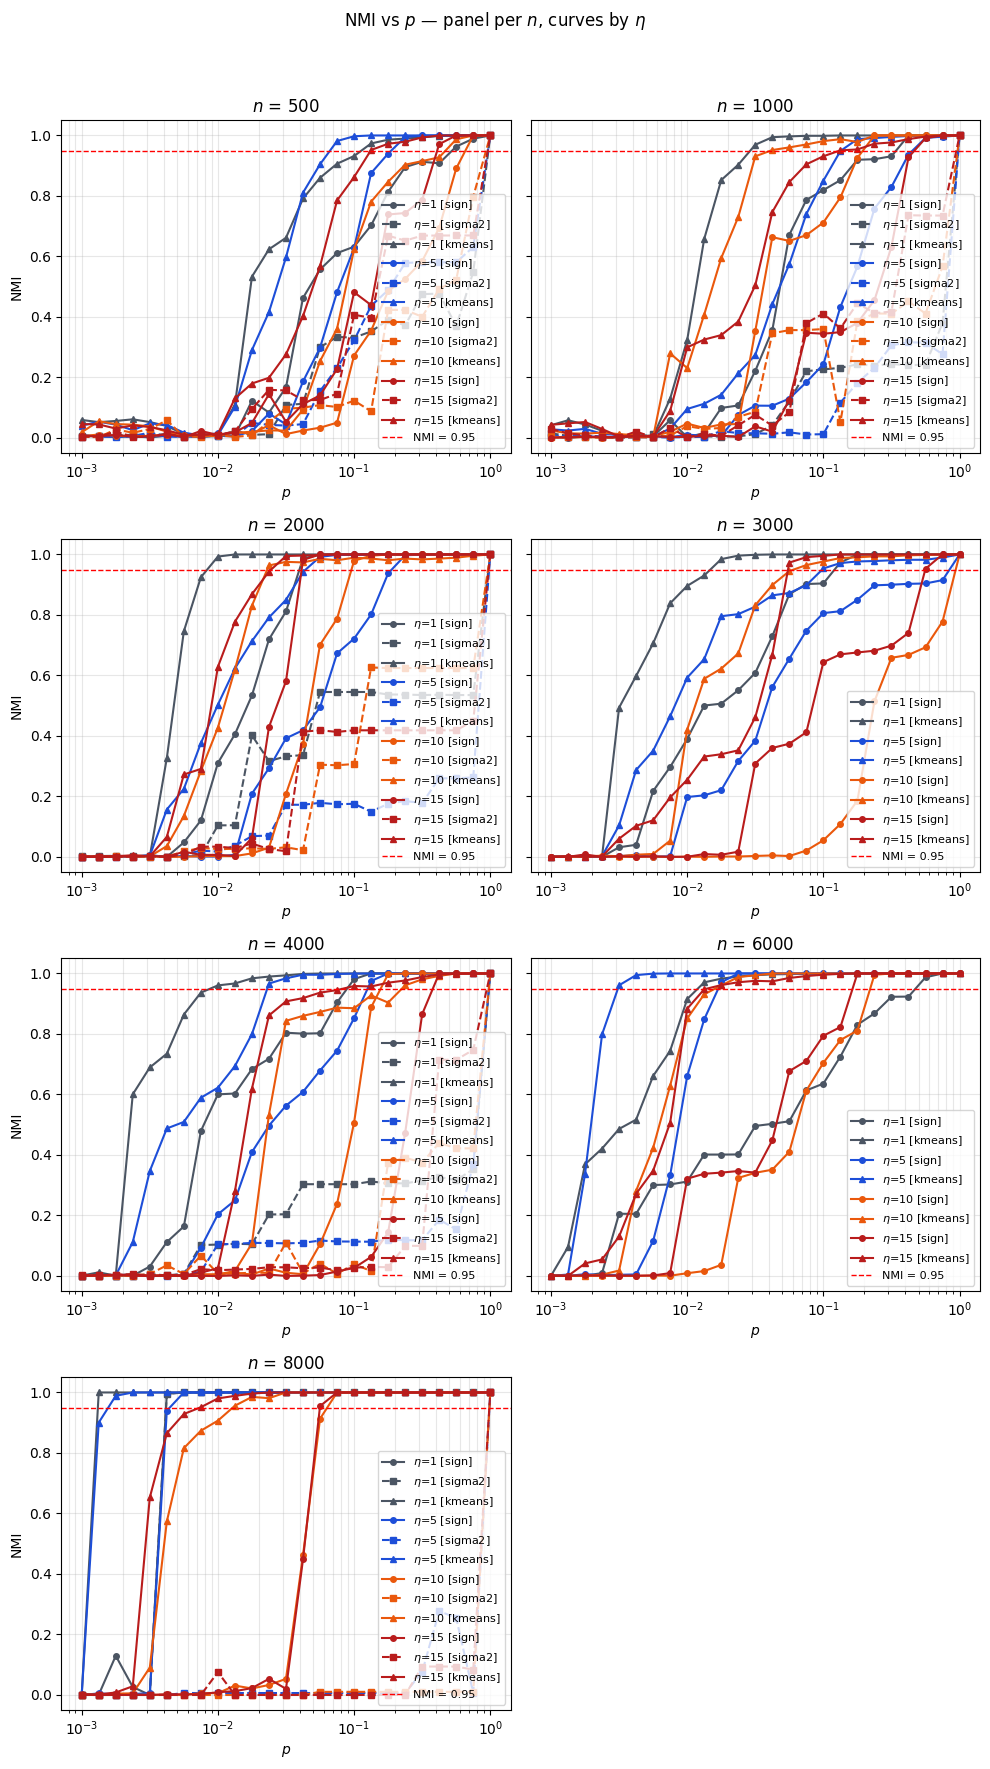

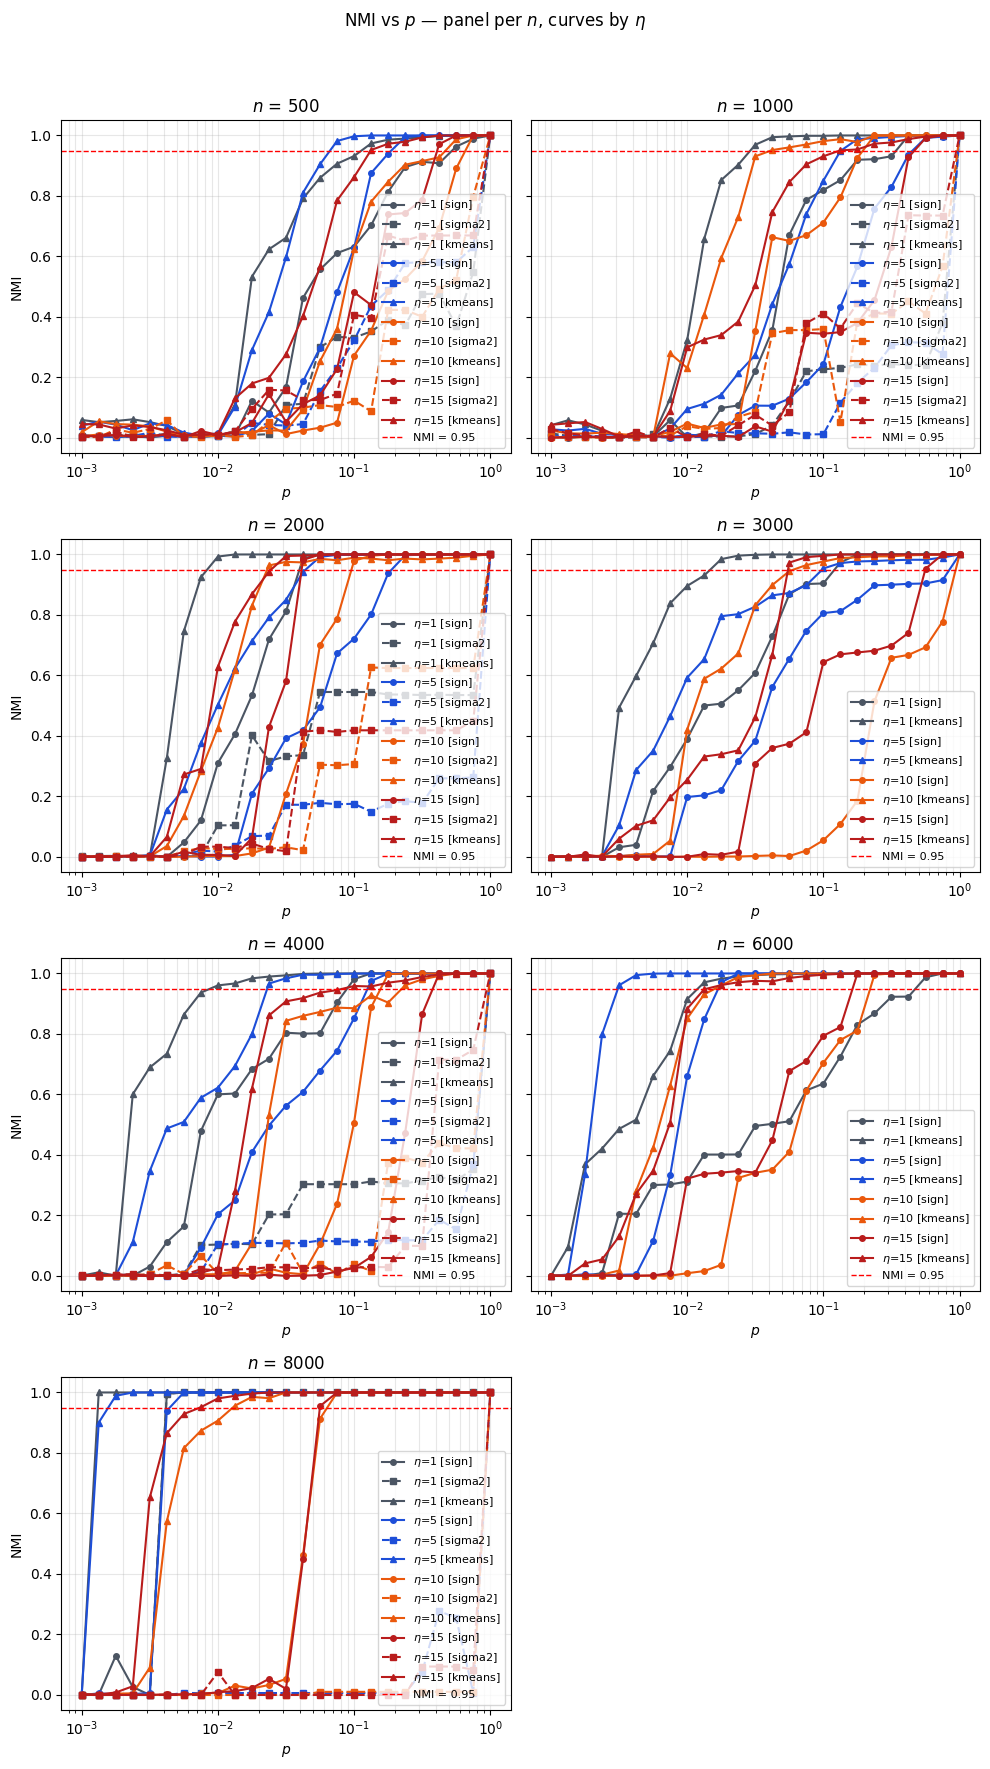

In [6]:
plot_curves_per_eta(results, P_VALUES, ETA_TARGETS, ns, METHODS,
                    agg=AGG, metric_label=METRIC.upper(), threshold=THRESHOLD)
plot_curves_per_n(results, P_VALUES, ETA_TARGETS, ns, METHODS,
                  agg=AGG, metric_label=METRIC.upper(), threshold=THRESHOLD)